# K-means 分群 (K-means Clustering)

學習目標：
- 了解非監督式學習的概念
- 學會 K-means 分群原理
- 用 Elbow Method 找最佳 K 值
- 把運動員依表現分群

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

## 1. 非監督式學習

之前的分類（KNN、隨機森林）都需要「標籤」：
告訴模型哪個是菁英、哪個是一般。

K-means 不需要標籤：
給它一堆資料，它自己找出「自然分群」。

運動員應用：
不預設分類，讓資料自己告訴你
運動員自然分成幾個族群。

In [2]:
# 建立模擬運動員資料
np.random.seed(42)

# 三個自然群體：菁英、中等、新手
elite    = np.random.randn(80, 2) + [8, 8]
medium   = np.random.randn(120, 2) + [4, 4]
beginner = np.random.randn(100, 2) + [1, 1]

X = np.vstack([elite, medium, beginner])
labels_true = np.array([0]*80 + [1]*120 + [2]*100)

# 標準化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'總資料筆數：{len(X)}')
print(f'菁英：80, 中等：120, 新手：100')

總資料筆數：300
菁英：80, 中等：120, 新手：100


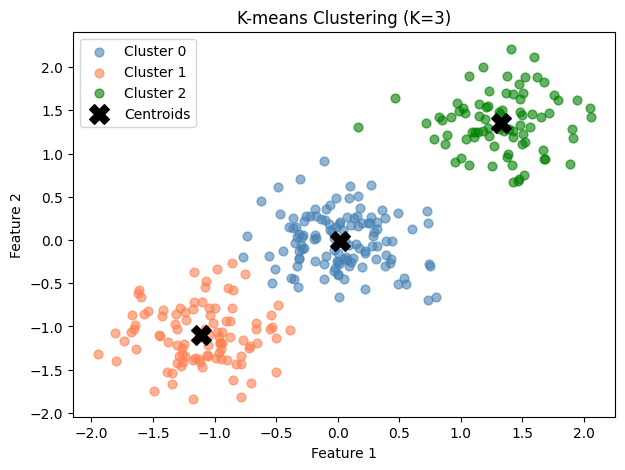

In [3]:
# K-means 分群（K=3）
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_scaled)
cluster_labels = kmeans.labels_

# 視覺化
colors = ['steelblue', 'coral', 'green']
plt.figure(figsize=(7, 5))
for i in range(3):
    mask = cluster_labels == i
    plt.scatter(X_scaled[mask, 0], X_scaled[mask, 1],
                color=colors[i], alpha=0.6, s=40,
                label=f'Cluster {i}')

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1],
            c='black', marker='X', s=200,
            zorder=5, label='Centroids')
plt.title('K-means Clustering (K=3)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

## 2. Elbow Method — 找最佳 K 值

K-means 需要事先指定 K，
Elbow Method 幫我們找最合適的 K：
畫出不同 K 值對應的誤差，
「手肘轉折點」就是最佳 K。

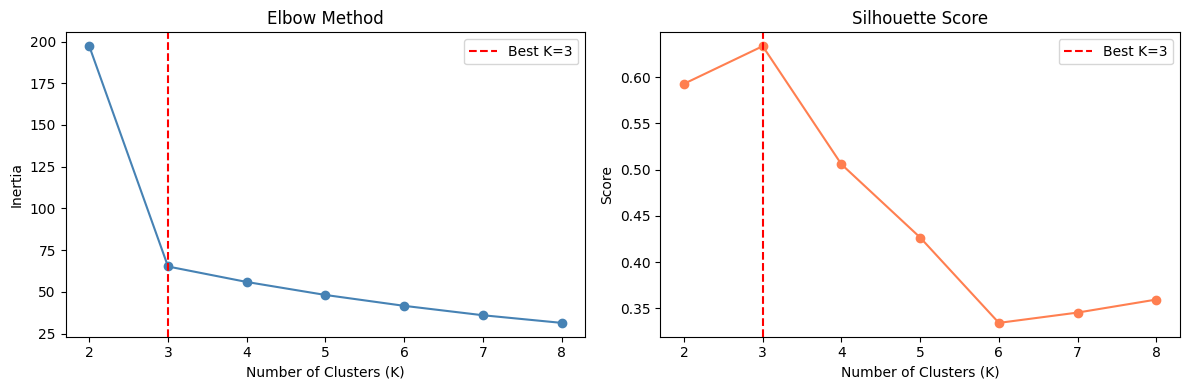

Silhouette Score 最高的 K = 3


In [4]:
# Elbow Method
inertias = []
silhouettes = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(k_range, inertias, 'o-', color='steelblue')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].axvline(x=3, color='red', linestyle='--',
                label='Best K=3')
axes[0].legend()

axes[1].plot(k_range, silhouettes, 'o-', color='coral')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Score')
axes[1].axvline(x=3, color='red', linestyle='--',
                label='Best K=3')
axes[1].legend()

plt.tight_layout()
plt.show()

best_k = k_range.start + silhouettes.index(max(silhouettes))
print(f'Silhouette Score 最高的 K = {best_k}')

## 3. 我的學習筆記

1. 這個主題在做什麼：
   不給標籤，讓演算法自己找出資料的自然分群，
   並用 Elbow Method 和 Silhouette Score
   找出最合適的群數 K。

2. 兩個評估指標：
   - Inertia：群內距離總和，越小越好
   - Silhouette Score：群間距離/群內距離，越接近1越好

3. 我覺得最難理解的地方：
   too hard

4. 這個跟我研究的連結：
   分析大量運動員資料時，
   可以先用 K-means 找出自然族群，
   再針對每個族群建立不同的預測模型，
   這比「全部一起建模」更精準。